In [ ]:
import os
# print(os.listdir("/kaggle/input"))
# print(os.listdir("/kaggle/input/uci-semcom"))

import pandas as pd
path = "/kaggle/input/uci-semcom/uci-secom.csv" # 資料來源：https://www.kaggle.com/datasets/paresh2047/uci-semcom
df = pd.read_csv(path)

print(df.shape)
df.head()

In [ ]:
import numpy as np
import pandas as pd

# stg1_資料清理
df = df.rename(columns=lambda c: str(c).strip())
df['Pass/Fail'] = df['Pass/Fail'].replace({-1:0, 1:1}).astype(int)
if 'Time' in df.columns:
    df['Time'] = pd.to_datetime(df['Time'], errors='coerce')

feature_cols = [c for c in df.columns if c not in ['Pass/Fail','Time']]
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')

## drop缺失資料太多的樣本
drop_cols = [c for c in feature_cols if df[c].isna().mean() > 0.7] # drop缺失比 > 70% 的感測器
keep_base = [c for c in feature_cols if c not in drop_cols]

## 有缺失的欄位標註標籤
miss_cols = [c for c in keep_base if df[c].isna().any()]
for c in miss_cols:
    df[f"{c}__isna"] = df[c].isna().astype(int)

In [3]:
# stg2_切分訓練/測試集
from sklearn.model_selection import train_test_split
X_all = df[[*keep_base, *[f"{c}__isna" for c in miss_cols]]]
y = df['Pass/Fail'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, stratify=y, random_state=42
)

# stg3_缺值處理(針對訓練集做KNN補值, 標準化）
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

pipe = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5, weights="distance")),
    ("scaler", StandardScaler())
])

X_train_np = pipe.fit_transform(X_train)
X_test_np  = pipe.transform(X_test)

ROC-AUC: 0.7282626361124654
              precision    recall  f1-score   support

           0     0.9327    0.9932    0.9620       293
           1     0.0000    0.0000    0.0000        21

    accuracy                         0.9268       314
   macro avg     0.4663    0.4966    0.4810       314
weighted avg     0.8703    0.9268    0.8976       314

[[291   2]
 [ 21   0]]


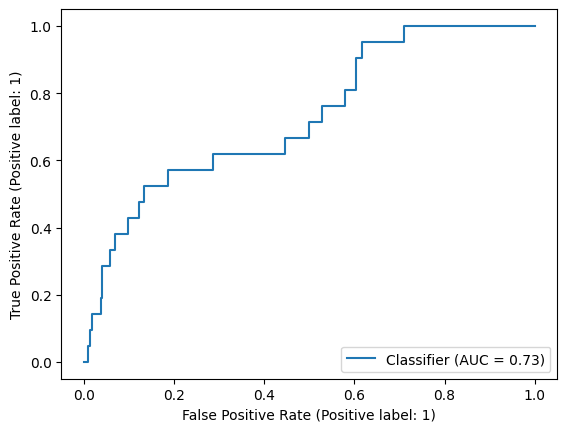

In [4]:
# stg4_Modeling(ML):
## 4.1 MacheineLearning_Supervised: XGBoost(製程良率分類)
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay

### 計算正負樣本比例(因pos比例較少, 以neg/pos比例做為權重)
pos_weight = (y_train==0).sum() / (y_train==1).sum()

### 初始化 XGBoost 模型超參數, 並訓練
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    scale_pos_weight=pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_np, y_train)

### 預測結果
y_prob = xgb.predict_proba(X_test_np)[:,1] # predict_proba 回傳[P(0), P(1)] → 取column2(Fail)
y_pred = (y_prob >= 0.5).astype(int) # 將機率轉為分類結果（閾值 0.5）

### 評估模型效能&畫圖
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred, digits=4))
print(confusion_matrix(y_test, y_pred))
_ = RocCurveDisplay.from_predictions(y_test, y_prob)


## 4.2 MacheineLearning_Unsupervised: Isolation Forest(製程異常偵測)
from sklearn.ensemble import IsolationForest
contam = float(y_train.mean()) # 預期異常比例

### 建立訓練模型
contam = min(max(contam, 1e-4), 0.5)  # clamp to (0, 0.5）
iso = IsolationForest(contamination=contam, random_state=42)
iso.fit(X_train_np)

### 計算異常分數
iso_score = -iso.score_samples(X_test_np) # 異常分數(越大越異常的分數)

### 轉成二元分類結果
iso_pred = (iso.predict(X_test_np) == -1).astype(int)  # IsolationForest.predict()回傳1=正常, -1=異常）

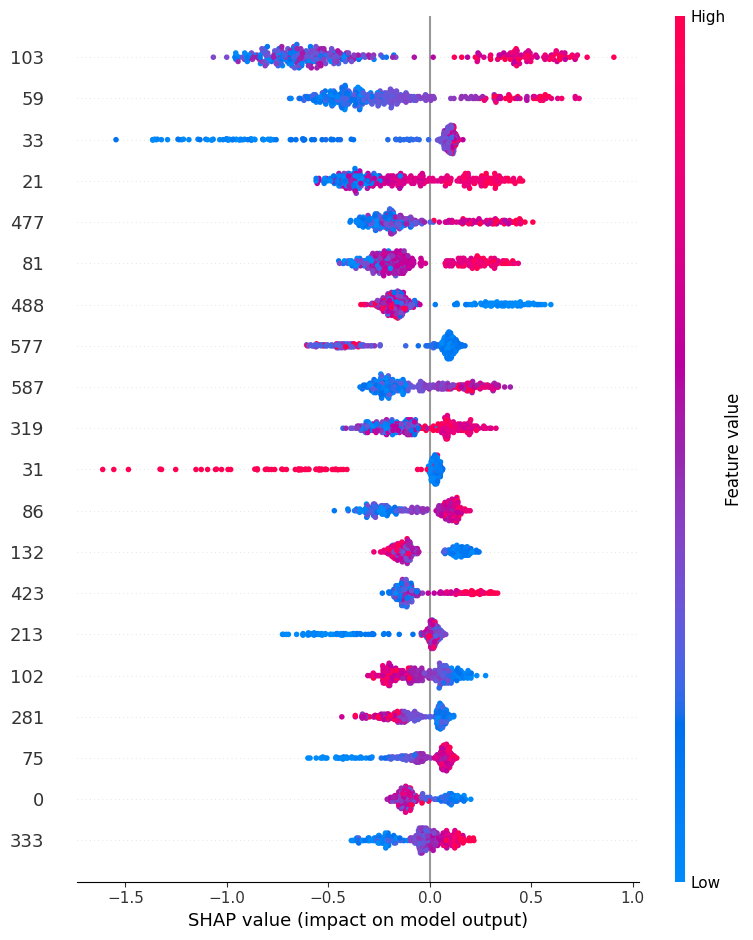

Top-20 features by XGBoost importance:
 [('319', 0.018567658960819244), ('103', 0.016017325222492218), ('162', 0.015000867657363415), ('297', 0.0130687290802598), ('453', 0.011540002189576626), ('489', 0.010661817155778408), ('455', 0.010182468220591545), ('130', 0.010023285634815693), ('338', 0.008819921873509884), ('518', 0.008783083409070969), ('31', 0.008536409586668015), ('556', 0.008135754615068436), ('385', 0.007864878512918949), ('144', 0.007615814916789532), ('476', 0.007296841591596603), ('433', 0.0071846297942101955), ('33', 0.0071577588096261024), ('60', 0.007118546403944492), ('70', 0.007067705038934946), ('7', 0.006973859388381243)]


In [5]:
# stg5_Evaluation
## 5.1 SHAP (XGBoost)
import shap
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_np) # 計算測試集的 SHAP 值
shap.summary_plot(shap_values, X_test_np, feature_names=X_all.columns.tolist())
# summary_plot(X:特徵對模型影響的程度（正/負),Y:特徵(按重要性排序), 顏色:特徵值大小（紅=高,藍=低）

## 5.2 特徵重要度 (XGBoost)
import numpy as np
fi = xgb.feature_importances_ # 特徵重要度
top_idx = np.argsort(fi)[::-1][:20] # 前20個重要的特徵
top_features = [(X_all.columns[i], float(fi[i])) for i in top_idx]
print("Top-20 features by XGBoost importance:\n", top_features)

[XGBoost] ROC-AUC = 0.7283
              precision    recall  f1-score   support

           0     0.9327    0.9932    0.9620       293
           1     0.0000    0.0000    0.0000        21

    accuracy                         0.9268       314
   macro avg     0.4663    0.4966    0.4810       314
weighted avg     0.8703    0.9268    0.8976       314

[IsoForest] ROC-AUC (scores vs. label) = 0.5830
              precision    recall  f1-score   support

           0     0.9309    0.9659    0.9481       293
           1     0.0000    0.0000    0.0000        21

    accuracy                         0.9013       314
   macro avg     0.4655    0.4829    0.4740       314
weighted avg     0.8687    0.9013    0.8847       314



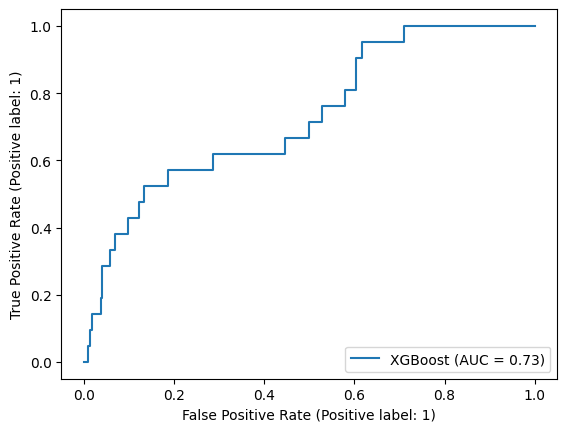

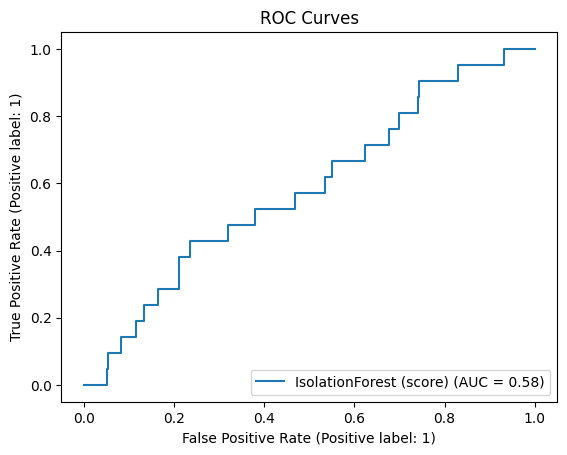

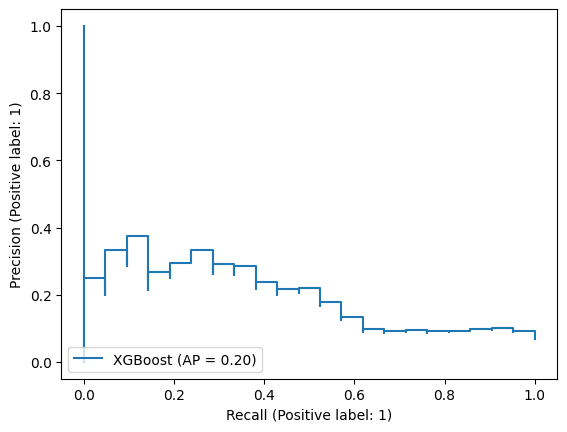

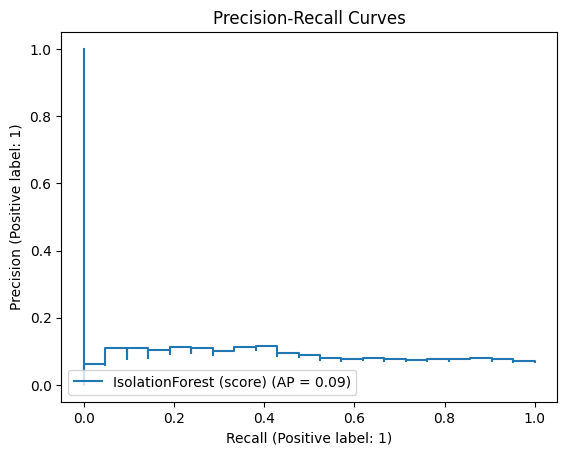

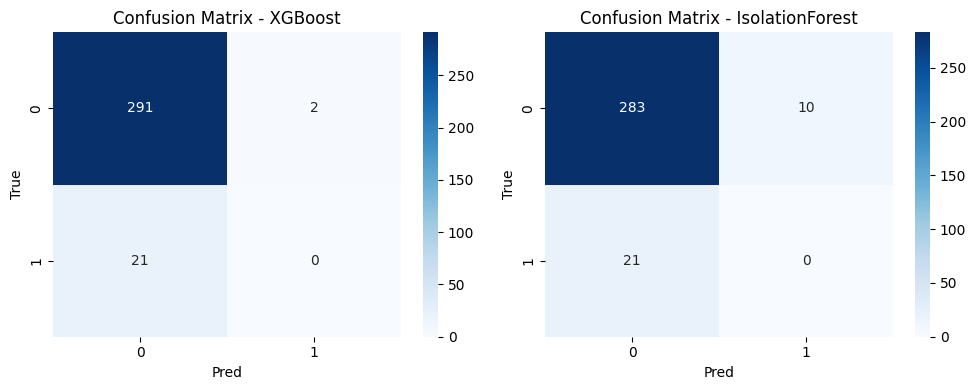

In [6]:
## 5.3 模型效能比較 (XGBoost + IsolationForest)
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

### Precision、Recall、F1、ROC-AUC
print(f"[XGBoost] ROC-AUC = {roc_auc_score(y_test, y_prob):.4f}") # XGBoost
print(classification_report(y_test, y_pred, digits=4)) # XGBoost
print(f"[IsoForest] ROC-AUC (scores vs. label) = {roc_auc_score(y_test, iso_score):.4f}") # Isolation Forest
print(classification_report(y_test, iso_pred, digits=4)) # Isolation Forest

### ROC
RocCurveDisplay.from_predictions(y_test, y_prob, name="XGBoost")
RocCurveDisplay.from_predictions(y_test, iso_score, name="IsolationForest (score)")
plt.title("ROC Curves"); plt.show()

### PR
PrecisionRecallDisplay.from_predictions(y_test, y_prob, name="XGBoost")
PrecisionRecallDisplay.from_predictions(y_test, iso_score, name="IsolationForest (score)")
plt.title("Precision-Recall Curves"); plt.show()

### Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", ax=axes[0]) # XGBoost
axes[0].set_title("Confusion Matrix - XGBoost"); axes[0].set_xlabel("Pred"); axes[0].set_ylabel("True") # XGBoost
sns.heatmap(confusion_matrix(y_test, iso_pred), annot=True, fmt="d", cmap="Blues", ax=axes[1]) # Isolation Forest
axes[1].set_title("Confusion Matrix - IsolationForest"); axes[1].set_xlabel("Pred"); axes[1].set_ylabel("True") # Isolation Forest
plt.tight_layout(); plt.show()

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


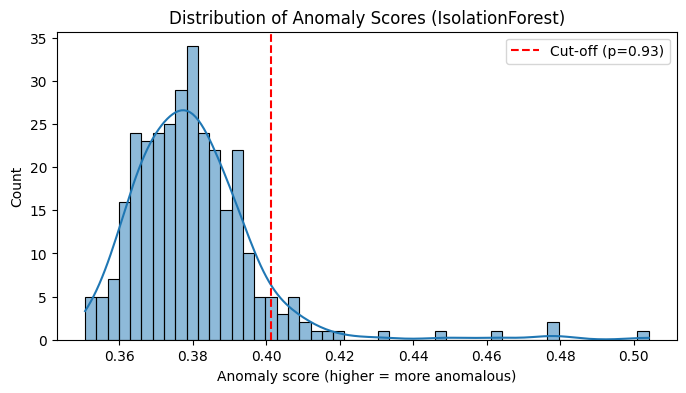

In [7]:
## 5.4 異常分數分佈(Anomaly Score Distribution_IsolationForest)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 看異常樣本大概落在哪個區域, 以測試集的真實fail比例給cut-off 參考線
fail_rate = float(np.mean(y_test)) # 例如實際fail的樣本佔 0.10
cutoff = np.percentile(iso_score, 100 * (1 - fail_rate)) # 則取到第90百分位

### 繪圖：異常分數直方圖 
plt.figure(figsize=(8,4))
sns.histplot(iso_score, bins=50, kde=True)
plt.axvline(cutoff, color='r', linestyle='--', label=f'Cut-off (p={1 - y_test.mean():.2f})')
plt.title("Distribution of Anomaly Scores (IsolationForest)")
plt.xlabel("Anomaly score (higher = more anomalous)")
plt.legend()
plt.show()

invalid value encountered in less


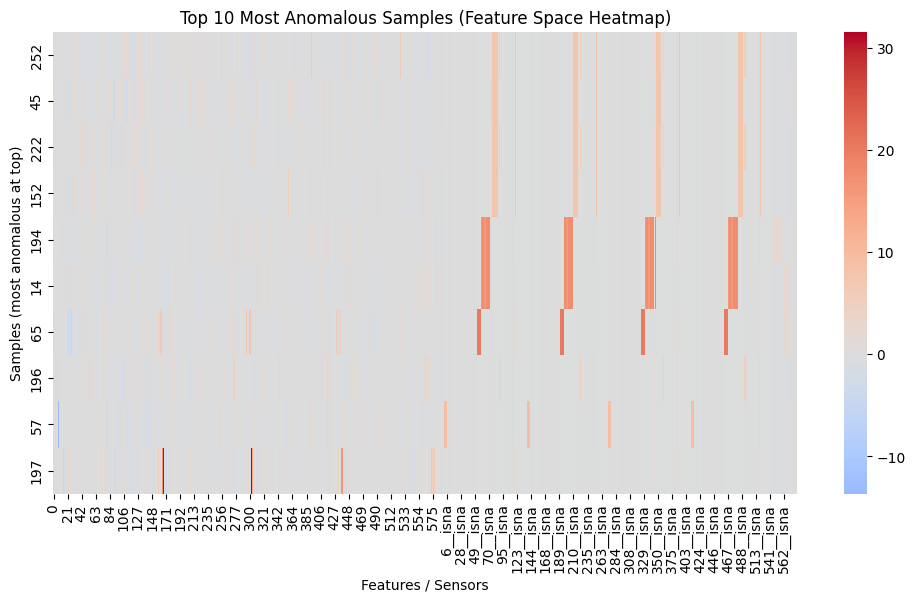

Top-20 features with largest variance among most-anomalous samples:
302          104.113529
167           99.573444
206__isna     55.867236
342__isna     55.867236
475__isna     55.867236
343__isna     55.867236
197__isna     55.867236
74__isna      55.867236
471__isna     55.867236
198__isna     55.867236
344__isna     55.867236
205__isna     55.867236
347__isna     55.867236
199__isna     55.867236
60__isna      55.867236
61__isna      55.867236
62__isna      55.867236
71__isna      55.867236
70__isna      55.867236
66__isna      55.867236
dtype: float64


In [8]:
## 5.5 Evaluation_Top-N Most Anomalous Samples Heatmap(測試資料中挑出異常分數最高的樣本，看看這些樣本在各個感測器的表現差異)
import pandas as pd

### 整合測試資料與異常資訊
N_TOP = 10 
iso_df = pd.DataFrame(X_test_np, columns=X_all.columns)
iso_df["anomaly_score"] = iso_score # 每筆樣本的異常分數
iso_df["label"] = y_test  # 0=Pass, 1=Fail
iso_df["pred_iforest"] = iso_pred  # IsolationForest 預測結果, 1=異常

### 取出前 N 筆異常樣本
top_anom = iso_df.sort_values("anomaly_score", ascending=False).head(N_TOP)

### 畫特徵Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    top_anom.drop(columns=["anomaly_score","label","pred_iforest"]),
    cmap="coolwarm", center=0
)
plt.title(f"Top {N_TOP} Most Anomalous Samples (Feature Space Heatmap)")
plt.ylabel("Samples (most anomalous at top)")
plt.xlabel("Features / Sensors")
plt.show()

### 變異最大的感測器(變異數（variance）最大sener最不穩定)
var_by_feature = top_anom.drop(columns=["anomaly_score","label","pred_iforest"]).var().sort_values(ascending=False)
print("Top-20 features with largest variance among most-anomalous samples:")
print(var_by_feature.head(20))

[AE] epoch 10/60  loss=0.635043
[AE] epoch 20/60  loss=0.480429
[AE] epoch 30/60  loss=0.419119
[AE] epoch 40/60  loss=0.377686
[AE] epoch 50/60  loss=0.344807
[AE] epoch 60/60  loss=0.318544
[AE] ROC-AUC (reconstruction error vs. label) = 0.5553


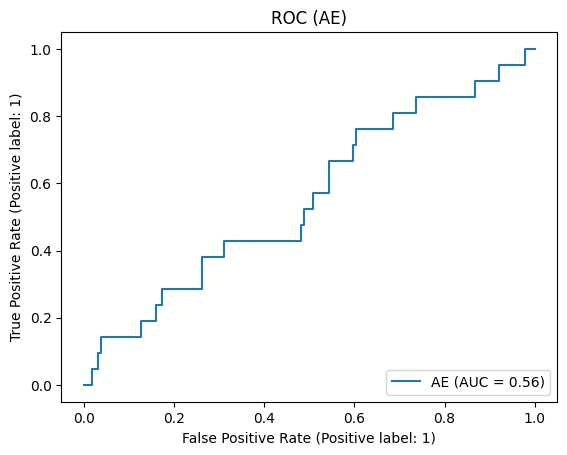

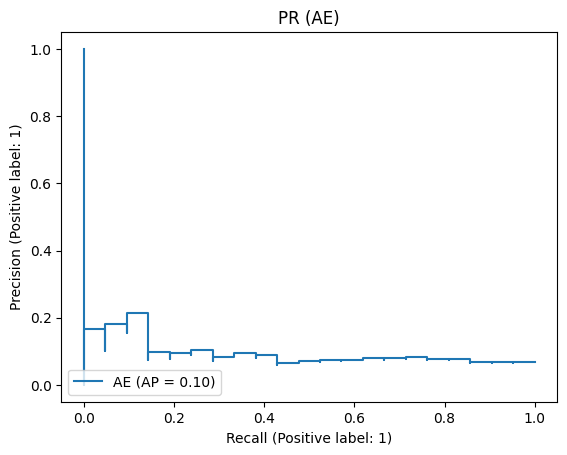

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


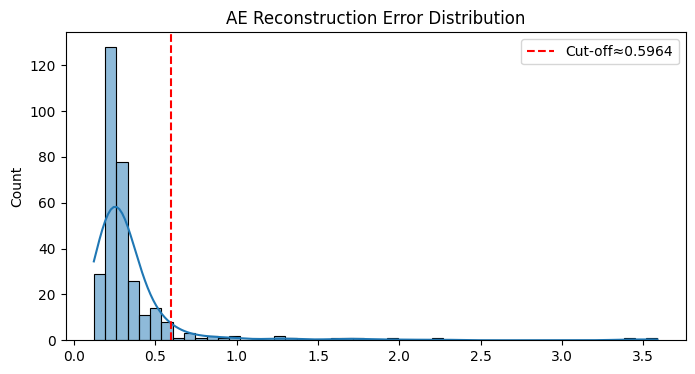

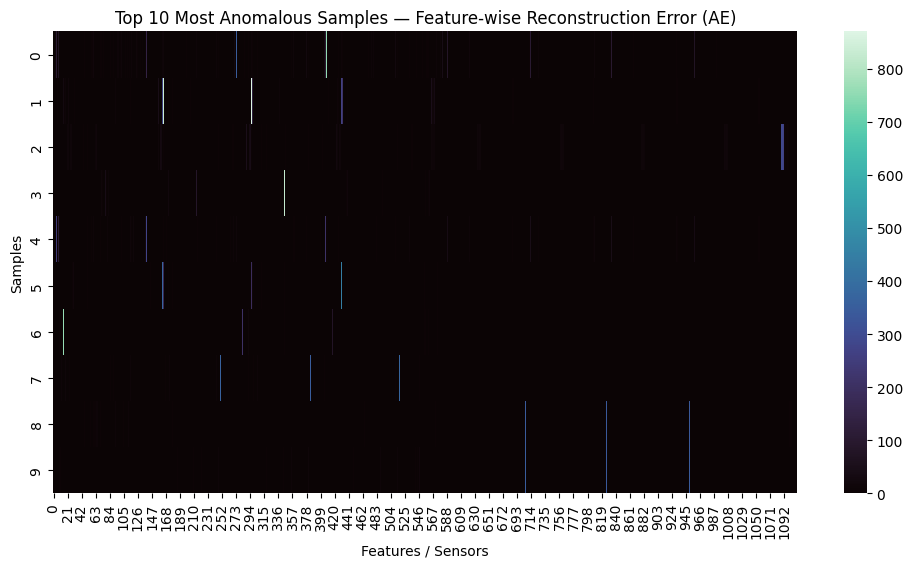

In [9]:
# stg6_Modeling(DeepLearning):
## 6.1 Autoencoder (AE) for Deep Anomaly Detection
import torch, torch.nn as nn, torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay

### 只用訓練集裡的正常樣本訓練 AE
X_train_ok = X_train_np[y_train == 0]
input_dim = X_train_np.shape[1] # 輸入維度 = 特徵數（補值＋標準化後的向量長度）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")# 自動選用 GPU（若有）以加速；否則使用 CPU

### 建立模型：簡單前饋式 Autoencoder：Encoder 壓縮、Decoder 重建
class AE(nn.Module):
    """Autoencoder：Encoder 壓縮、Decoder 重建"""
    def __init__(self, d_in):
        super().__init__()
        # Encoder：d_in → 256 → 128 → 32
        self.encoder = nn.Sequential(
            nn.Linear(d_in, 256), nn.ReLU(),
            nn.Linear(256, 128),  nn.ReLU(),
            nn.Linear(128, 32),   nn.ReLU(),
        )
        # Decoder：32 → 128 → 256 → d_in（輸出與輸入同維）
        self.decoder = nn.Sequential(
            nn.Linear(32, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, d_in),
        )
    def forward(self, x):
        z = self.encoder(x) # 壓縮到潛向量 z
        x_hat = self.decoder(z) # 從 z 重建回輸入空間
        return x_hat

def to_loader(np_array, batch_size=512, shuffle=True):
    """把 numpy 陣列包成 PyTorch DataLoader（僅特徵，無標籤）"""
    tens = torch.tensor(np_array, dtype=torch.float32)
    ds = torch.utils.data.TensorDataset(tens)
    return torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

### 初始化 AE、優化器與損失：MSE 重建誤差
ae = AE(input_dim).to(device)
opt = optim.Adam(ae.parameters(), lr=1e-3)
crit = nn.MSELoss(reduction="mean")
train_loader = to_loader(X_train_ok, batch_size=512, shuffle=True)

### 訓練：只最小化正常樣本的重建誤差
EPOCHS = 60
ae.train()
for ep in range(EPOCHS):
    loss_ep = 0.0
    for (xb,) in train_loader:
        xb = xb.to(device)
        opt.zero_grad()
        recon = ae(xb)
        loss = crit(recon, xb) # MSE：越小代表重建越好（越像正常）
        loss.backward()
        opt.step()
        loss_ep += loss.item() * len(xb)
    if (ep+1) % 10 == 0:
        print(f"[AE] epoch {ep+1}/{EPOCHS}  loss={loss_ep/len(train_loader.dataset):.6f}")

### 對測試集做重建，計算每筆樣本的重建誤差= 異常分數
ae.eval()
with torch.no_grad():
    Xt = torch.tensor(X_test_np, dtype=torch.float32, device=device)
    recon_t = ae(Xt).cpu().numpy()
    
recon_err = ((recon_t - X_test_np)**2).mean(axis=1)# 每筆樣本的 MSE=異常分數,越大越異常

### 與 y_test 比較，計算 ROC/PR
auc_ae = roc_auc_score(y_test, recon_err)
print(f"[AE] ROC-AUC (reconstruction error vs. label) = {auc_ae:.4f}")
RocCurveDisplay.from_predictions(y_test, recon_err, name="AE"); plt.title("ROC (AE)"); plt.show()
PrecisionRecallDisplay.from_predictions(y_test, recon_err, name="AE"); plt.title("PR (AE)"); plt.show()

### 重建誤差分布
plt.figure(figsize=(8,4))
sns.histplot(recon_err, bins=50, kde=True)

### 以「測試集實際 Fail 比例」當 cut-off 參考線
cut_ae = np.percentile(recon_err, 100*(1 - y_test.mean()))
plt.axvline(cut_ae, color='r', ls='--', label=f"Cut-off≈{cut_ae:.4g}")
plt.title("AE Reconstruction Error Distribution"); plt.legend(); plt.show()

### 取 Top-N 最大的重建殘差樣本，畫heatmap
N_TOP = 10
idx_top = np.argsort(recon_err)[-N_TOP:][::-1]
err_matrix = (recon_t - X_test_np)[idx_top]**2
plt.figure(figsize=(12,6))
sns.heatmap(err_matrix, cmap="mako", cbar=True)
plt.title(f"Top {N_TOP} Most Anomalous Samples — Feature-wise Reconstruction Error (AE)")
plt.xlabel("Features / Sensors"); plt.ylabel("Samples"); plt.show()

[VAE] epoch 10/60 loss=0.695888
[VAE] epoch 20/60 loss=0.490284
[VAE] epoch 30/60 loss=0.419448
[VAE] epoch 40/60 loss=0.368337
[VAE] epoch 50/60 loss=0.335701
[VAE] epoch 60/60 loss=0.311847
[VAE] ROC-AUC (reconstruction error vs. label) = 0.5560


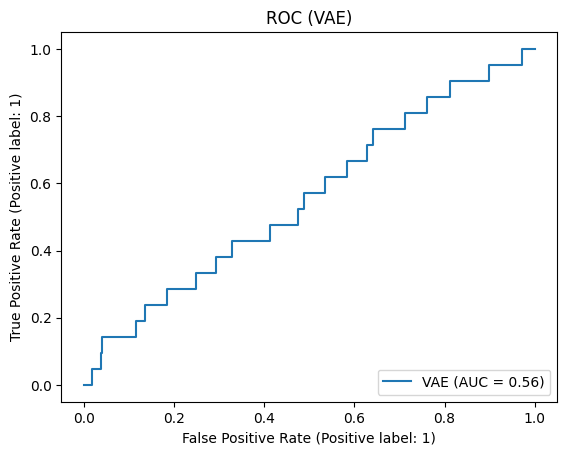

In [10]:
## 6.2 Variational Autoencoder(VAE)

class VAE(nn.Module):
    def __init__(self, d_in, d_lat=16):
        super().__init__()
        # Encoder 先抽取中階特徵，再各自輸出 μ 與 log(σ^2)
        self.enc = nn.Sequential(
            nn.Linear(d_in, 256), nn.ReLU(),
            nn.Linear(256, 128),  nn.ReLU()
        )
        self.mu     = nn.Linear(128, d_lat) # 潛空間的平均 μ
        self.logvar = nn.Linear(128, d_lat) # 潛空間的 log(σ^2)

        # Decoder：z → 重建輸入
        self.dec = nn.Sequential(
            nn.Linear(d_lat, 128), nn.ReLU(),
            nn.Linear(128, 256),   nn.ReLU(),
            nn.Linear(256, d_in)
        )
        
### 對輸入 x 所對應的潛向量 z 的分佈
    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)
### 重參數化抽樣
    def reparam(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std
        
### 供損失函數同時計算重建誤差與KL散度
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar) # 取樣潛向量 z
        x_hat = self.dec(z) # 從 z 解碼回輸入空間
        return x_hat, mu, logvar
        
### Loss = 重建誤差 + β × KL 散度
### (重建誤差：MSE(x_hat, x))、KL 散度：讓 q(z|x) 接近 N(0, I)，使潛空間更平滑可泛化
def vae_loss(x_hat, x, mu, logvar):
    rec = nn.functional.mse_loss(x_hat, x, reduction="mean")
    kl  = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return rec + 1e-3 * kl  # 以 1e-3 權重平衡重建與正則

### 初始化 VAE 與訓練設定（只用正常樣本）
vae = VAE(input_dim, d_lat=16).to(device)
opt = optim.Adam(vae.parameters(), lr=1e-3)
train_loader = to_loader(X_train_ok, batch_size=512, shuffle=True)

### 訓練並計算損失改為 VAE(重建＋KL)
EPOCHS = 60
vae.train()
for ep in range(EPOCHS):
    loss_ep = 0.0
    for (xb,) in train_loader:
        xb = xb.to(device)
        opt.zero_grad()
        x_hat, mu, logvar = vae(xb)
        loss = vae_loss(x_hat, xb, mu, logvar)
        loss.backward()
        opt.step()
        loss_ep += loss.item() * len(xb)
    if (ep+1) % 10 == 0:
        print(f"[VAE] epoch {ep+1}/{EPOCHS} loss={loss_ep/len(train_loader.dataset):.6f}")

# 重建誤差作為異常分數
vae.eval()
with torch.no_grad():
    Xt = torch.tensor(X_test_np, dtype=torch.float32, device=device)
    x_hat, mu, logvar = vae(Xt)
    recon_err_vae = ((x_hat.cpu().numpy() - X_test_np)**2).mean(axis=1)

# ROC/PR
auc_vae = roc_auc_score(y_test, recon_err_vae)
print(f"[VAE] ROC-AUC (reconstruction error vs. label) = {auc_vae:.4f}")
RocCurveDisplay.from_predictions(y_test, recon_err_vae, name="VAE"); plt.title("ROC (VAE)"); plt.show()


Model performance summary (higher is better):
  XGBoost (P[Fail])      ROC-AUC = 0.7283 | PR-AUC = 0.1987
  IsolationForest        ROC-AUC = 0.5830 | PR-AUC = 0.0905
  Autoencoder            ROC-AUC = 0.5553 | PR-AUC = 0.0963
  Variational AE         ROC-AUC = 0.5560 | PR-AUC = 0.0948


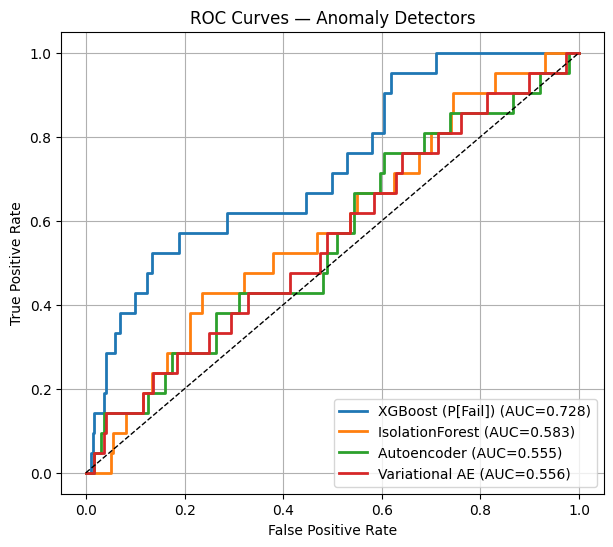

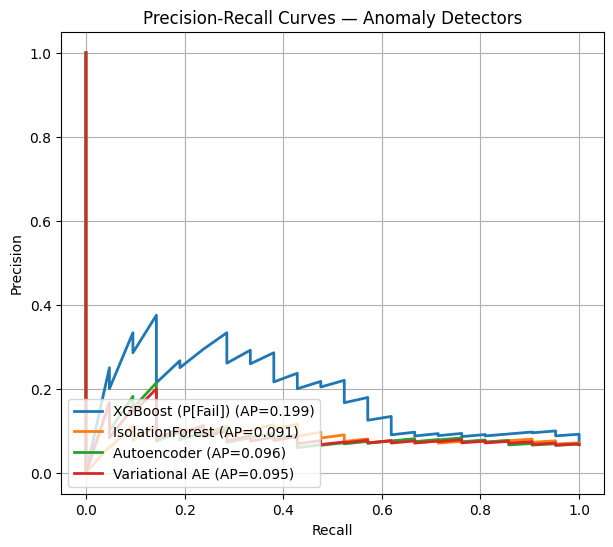

In [11]:
# stg7_模型比較(IsolationForest vs AE vs VAE vs XGBoost)
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt

pairs = []

### XGBoost(使用「Fail 的機率」當異常分數)
if 'y_prob' in globals():
    pairs.append(("XGBoost (P[Fail])", y_prob))
### IsolationForest(分數越大＝越異常）
if 'iso_score' in globals():
    pairs.append(("IsolationForest", iso_score))
### Autoencoder(分數越大＝越異常）    
if 'recon_err' in globals():
    pairs.append(("Autoencoder", recon_err))
### Variational AE(分數越大＝越異常）   
if 'recon_err_vae' in globals():
    pairs.append(("Variational AE", recon_err_vae))

### ROC-AUC & PR-AUC
print("Model performance summary (higher is better):")
summary_rows = []
for name, score in pairs:
    roc_auc = roc_auc_score(y_test, score)
    pr_auc  = average_precision_score(y_test, score)  # PR-AUC（AP）
    summary_rows.append((name, roc_auc, pr_auc))
    print(f"  {name:<22s} ROC-AUC = {roc_auc:.4f} | PR-AUC = {pr_auc:.4f}")

### ROC
plt.figure(figsize=(7,6))
for name, score in pairs:
    fpr, tpr, _ = roc_curve(y_test, score)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc_score(y_test, score):.3f})")
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.title("ROC Curves — Anomaly Detectors")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### PRECISION-RECALL
plt.figure(figsize=(7,6))
for name, score in pairs:
    precision, recall, _ = precision_recall_curve(y_test, score)
    ap = average_precision_score(y_test, score)
    plt.plot(recall, precision, lw=2, label=f"{name} (AP={ap:.3f})")
plt.title("Precision-Recall Curves — Anomaly Detectors")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()